In [1]:
import tensorflow as tf
import tensorflow_probability as tfp

import tf_keras # <-- use tf_keras with TFP
from tf_keras import layers
from tf_keras import backend as K

import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [5]:
def load_npz_from_url(url,key):
    response = requests.get(url)
    response.raise_for_status() # Ensure the request was successful

    # Load the data from the in-memory bytes
    with np.load(io.BytesIO(response.content), allow_pickle=True) as data:

        if key in data.files:
            array_data = data[key]
            df = pd.DataFrame(array_data)
            return df
        else:
            print("Specified key not found in the NPZ file.")
            return None


#### Load the training and testing data

In [8]:
url = 'https://github.com/Goucher-College-Data-Science/Capstone_Alee_Marschke/raw/main/'

trainURL = url + 'Baseball_Full_Train.npz'
testURL = url + 'Baseball_Full_Test.npz'

In [9]:
xTrain = load_npz_from_url( trainURL, 'xTrain' )
yTrain = load_npz_from_url( trainURL, 'yTrain' )

xTest = load_npz_from_url( testURL, 'xTest' )
yTest = load_npz_from_url( testURL, 'yTest' )

In [10]:
xTrain = xTrain.to_numpy()
yTrain = yTrain.to_numpy()

xTest = xTest.to_numpy()
yTest = yTest.to_numpy()

#### We don't need all the available data for this demo

#### Keep just the strikeouts per plate appearance

In [11]:
xTrain = xTrain[:, 7] / xTrain[:,1]
xTest = xTest[:, 7] / xTest[:,1]

yTrain = yTrain[:,1]
yTest = yTest[:,1]

In [12]:
xTrain.shape, yTrain.shape, xTest.shape, yTest.shape

((1016,), (1016,), (339,), (339,))

#### Training Data

(0.0, 0.5)

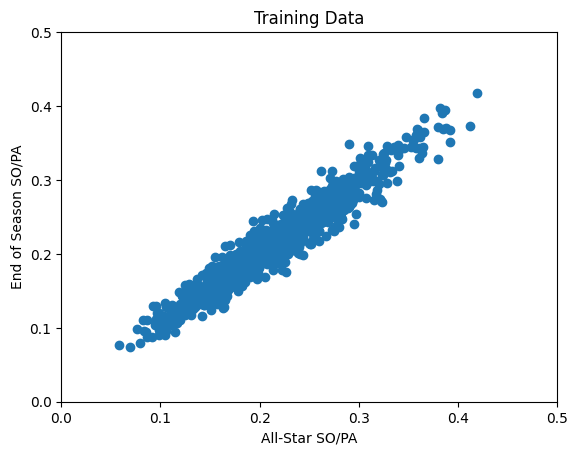

In [ ]:
plt.scatter(xTrain, yTrain)
plt.title('Training Data')
plt.xlabel('All-Star SO/PA')
plt.ylabel('End of Season SO/PA')
plt.xlim(0,.5)
plt.ylim(0,.5)

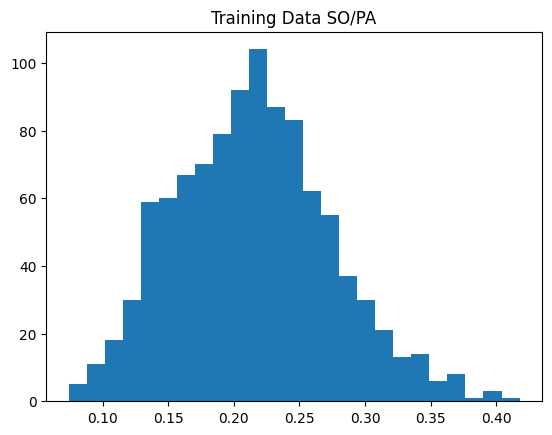

In [ ]:
plt.hist(yTrain, bins=25)
plt.title("Training Data SO/PA")
plt.show()

#### Define the Bayesian Neural Network

In [ ]:
# Negative Log Likelihood loss function
def nll(y_true, y_pred):
    return -y_pred.log_prob(y_true)

In [ ]:
tfd = tfp.distributions

# Define the prior weight distribution as Normal of mean=0 and stddev=1.
def prior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    prior_model = tf_keras.Sequential(
        [
            tfp.layers.DistributionLambda(
                lambda t: tfp.distributions.MultivariateNormalDiag(
                    loc=tf.zeros(n), scale_diag=tf.ones(n)
                )
            )
        ]
    )
    return prior_model


# Define variational posterior weight distribution
def posterior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return tf_keras.Sequential([
        tfp.layers.VariableLayer(2 * n, dtype=dtype), tfp.layers.DistributionLambda(
            lambda t: tfd.Independent(tfd.Normal(loc=t[..., :n], scale=tf.nn.softplus(t[..., n:])),
              reinterpreted_batch_ndims=1))
     ])

In [ ]:
inputs = tf_keras.layers.Input( 1 )

# first hidden layer
hidden1 = tfp.layers.DenseVariational(units=12,
                                      make_prior_fn=prior,
                                      make_posterior_fn=posterior,
                                      kl_weight=0.1/len(xTrain),
                                      activation='sigmoid')(inputs)

# second hidden layer
hidden2 = tfp.layers.DenseVariational(units=6,
                                      make_prior_fn=prior,
                                      make_posterior_fn=posterior,
                                      kl_weight=0.1/len(xTrain),
                                      activation='sigmoid')(hidden1)

# Define output layer with 2 parameters (mean and variance)
distribution_params = layers.Dense(units=2)(hidden2)
outputs = tfp.layers.IndependentNormal(1)(distribution_params)

bnn = tf_keras.Model(inputs=inputs, outputs=outputs)

bnn.compile(loss=nll, optimizer=tf_keras.optimizers.RMSprop(learning_rate=0.001))

In [ ]:
bnn.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 dense_variational (DenseVa  (None, 12)                48        
 riational)                                                      
                                                                 
 dense_variational_1 (Dense  (None, 6)                 156       
 Variational)                                                    
                                                                 
 dense (Dense)               (None, 2)                 14        
                                                                 
 independent_normal (Indepe  ((None, 1),               0         
 ndentNormal)                 (None, 1))                         
                                                             

#### Train the BNN

In [ ]:
from keras import backend as K

# Keras keeps models hanging around in memory. If we retrain a model, Keras will
# start from the previously concluded weight values. This resets everything.
K.clear_session()

In [ ]:
history = bnn.fit( xTrain, yTrain, epochs=5000, batch_size=64 )

Streaming output truncated to the last 5000 lines.
16/16 [==============================] - 0s 3ms/step - loss: -2.5974
Epoch 2502/5000
16/16 [==============================] - 0s 3ms/step - loss: -2.5995
Epoch 2503/5000
16/16 [==============================] - 0s 3ms/step - loss: -2.5669
Epoch 2504/5000
16/16 [==============================] - 0s 3ms/step - loss: -2.5435
Epoch 2505/5000
16/16 [==============================] - 0s 4ms/step - loss: -2.6065
Epoch 2506/5000
16/16 [==============================] - 0s 3ms/step - loss: -2.6518
Epoch 2507/5000
16/16 [==============================] - 0s 3ms/step - loss: -2.6413
Epoch 2508/5000
16/16 [==============================] - 0s 3ms/step - loss: -2.5453
Epoch 2509/5000
16/16 [==============================] - 0s 3ms/step - loss: -2.6032
Epoch 2510/5000
16/16 [==============================] - 0s 3ms/step - loss: -2.6154
Epoch 2511/5000
16/16 [==============================] - 0s 3ms/step - loss: -2.6397
Epoch 2512/5000
16/16 [=======

Text(0, 0.5, 'Negative Log Likelihood')

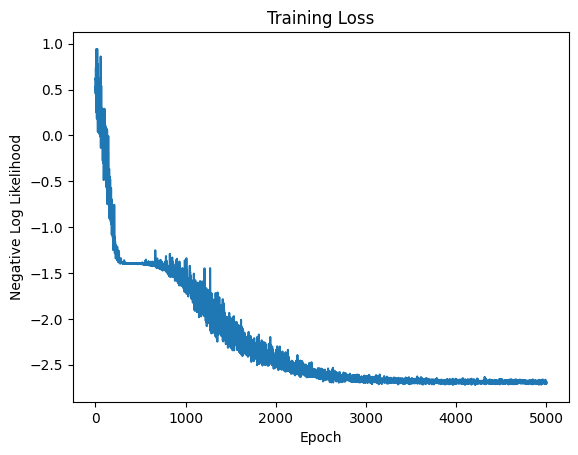

In [ ]:
plt.plot( np.arange(0,5000,1), history.history['loss'] )
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log Likelihood')

#### Predictions and uncertainty

In [ ]:
# 1000 predictions for every player in our test set
n = 1000

# we are predicting a normal distribution
# every prediction will have a mean and variance
means = np.zeros( shape=(n,len(xTest)) )
variances = np.zeros( shape=(n,len(xTest)) )

for i in range(n):

    # print a status message so we know where we are in the loop
    if ( i == 250 ): print("Completed 250 forward passes...")
    if ( i == 500 ): print("Completed 500 forward passes...")
    if ( i == 750 ): print("Completed 750 forward passes...")

    predictions = bnn(xTest)
    means[i,:] = np.array( predictions.mean()[:,0] )
    variances[i,:] = np.array( predictions.variance()[:,0] )

means.shape, variances.shape


Completed 250 forward passes...
Completed 500 forward passes...
Completed 750 forward passes...


((1000, 339), (1000, 339))

In [ ]:
# final prediction is the mean of the 1000 predictions
predictions = np.mean( means, axis=0 )
predictions.shape

(339,)

In [ ]:
# Aleatoric Uncertainty - mean of the variances
aleatoric = np.mean( variances, axis=0 )

# Epistemic Uncertainty - variances of the means
epistemic = np.var( means, axis=0 )

aleatoric.shape, epistemic.shape

((339,), (339,))

In [ ]:
# MAE
mean_absolute_error(predictions, yTest)

0.013741068029964703

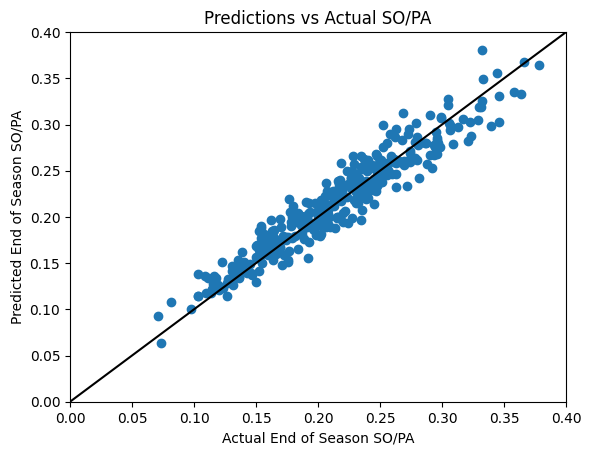

In [ ]:
plt.scatter( yTest, predictions )
plt.xlim(0,.4)
plt.ylim(0,.4)
plt.title('Predictions vs Actual SO/PA')
plt.xlabel('Actual End of Season SO/PA')
plt.ylabel('Predicted End of Season SO/PA')
plt.plot(np.arange(0,1,.1),np.arange(0,1,.1), color='black')

Text(0.5, 0, 'Residual')

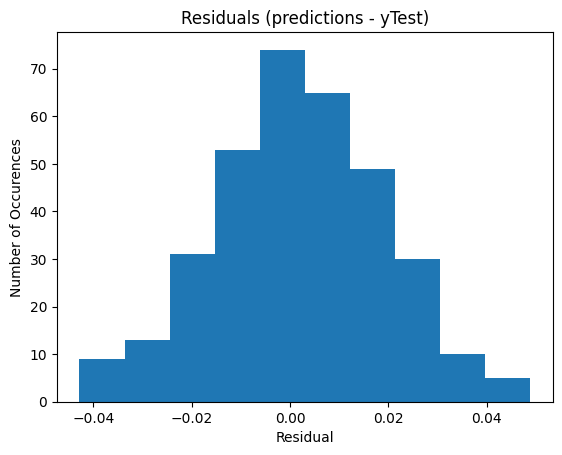

In [ ]:
r = predictions - yTest
plt.hist(r)
plt.title('Residuals (predictions - yTest)')
plt.ylabel('Number of Occurences')
plt.xlabel('Residual')

Edit substack BNN article - make prediction with prediction interval, scatter plot of aleatoric vs epistemic,

Text(0.5, 0, 'Uncertainty')

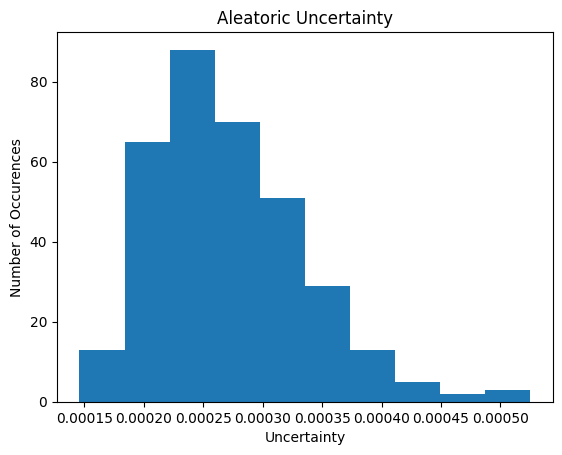

In [ ]:
plt.hist( aleatoric )
plt.title('Aleatoric Uncertainty')
plt.ylabel('Number of Occurences')
plt.xlabel('Uncertainty')

Text(0.5, 0, 'Uncertainty')

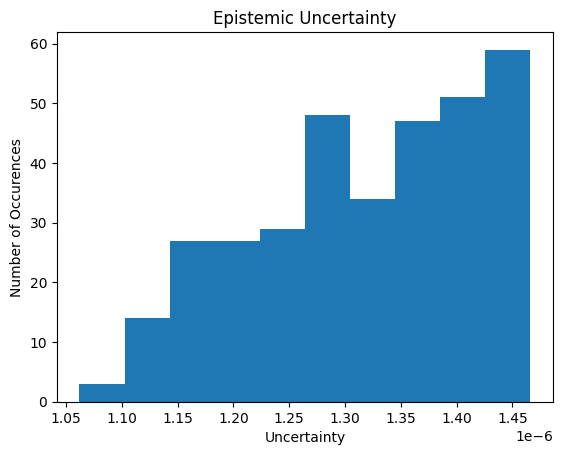

In [ ]:
plt.hist( epistemic )
plt.title('Epistemic Uncertainty')
plt.ylabel('Number of Occurences')
plt.xlabel('Uncertainty')

In [ ]:
# prediction intervals

samples = np.zeros( shape=(n, len(xTest)) )

for i in range( len(xTest) ):
  for j in range(n):
    m = means[j,i]
    sd = np.sqrt( variances[j,i] )
    samples[j,i] = np.random.normal( m, sd )

In [ ]:
plows = np.zeros( shape=(len(xTest)) )
phighs = np.zeros( shape=(len(xTest)) )

for i in range( len(xTest) ):
  plow = np.percentile(samples[:,i], 2.5)
  phigh = np.percentile(samples[:,i], 97.5)
  plows[i] = plow
  phighs[i] = phigh

In [ ]:
# player 42
print("Prediction Interval:", np.round(plows[42],3), np.round(phighs[42],3))
print("Point estimate prediction:", np.round(predictions[42],3))
print("Actual SO/PA:", np.round(yTest[42],3))
print("Epistemic:", epistemic[42])
print("Aleatoric:", np.round(aleatoric[42],4))

Prediction Interval: 0.107 0.161
Point estimate prediction: 0.135
Actual SO/PA: 0.132
Epistemic: 1.1548570800543568e-06
Aleatoric: 0.0002


Text(0, 0.5, 'Prediction Interval Width')

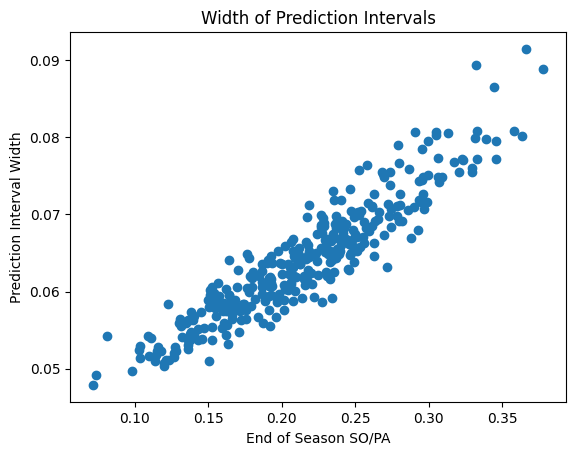

In [ ]:
widths = phighs - plows
plt.scatter( yTest, widths )
plt.title('Width of Prediction Intervals')
plt.xlabel('End of Season SO/PA')
plt.ylabel('Prediction Interval Width')

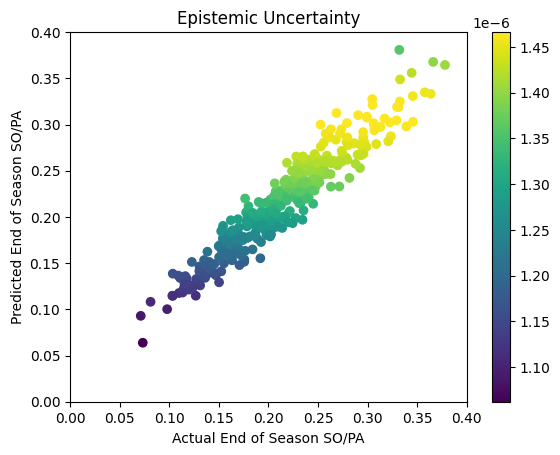

In [ ]:
plt.scatter( yTest, predictions, c=epistemic, cmap='viridis' )
plt.xlim(0,.4)
plt.ylim(0,.4)
plt.title('Epistemic Uncertainty')
plt.xlabel('Actual End of Season SO/PA')
plt.ylabel('Predicted End of Season SO/PA')
plt.colorbar()

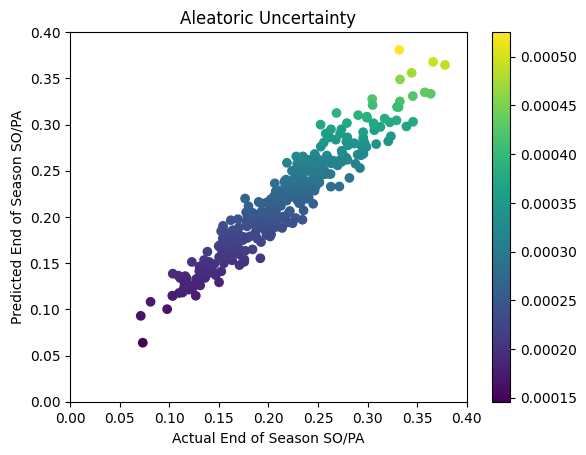

In [ ]:
plt.scatter( yTest, predictions, c=aleatoric, cmap='viridis' )
plt.xlim(0,.4)
plt.ylim(0,.4)
plt.title('Aleatoric Uncertainty')
plt.xlabel('Actual End of Season SO/PA')
plt.ylabel('Predicted End of Season SO/PA')
plt.colorbar()